C:\Users\morit\AppData\Local\Temp\ipykernel_14392\1882750288.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


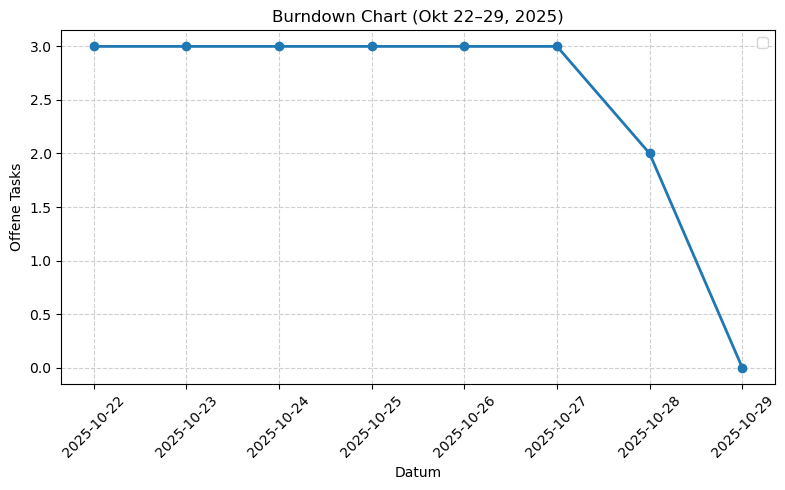

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the time range and task data
dates = pd.date_range("2025-10-22", "2025-10-29")
tasks_total = 3

# Burndown data: all tasks open until Oct 26, one done on Oct 27, rest on Oct 28
remaining_tasks = [3, 3, 3, 3, 3, 3, 2, 0]

# Create DataFrame
data = pd.DataFrame({
    "Date": dates,
    "Remaining Tasks": remaining_tasks
})

# Plot the burndown chart
plt.figure(figsize=(8, 5))
plt.plot(data["Date"], data["Remaining Tasks"], marker="o", linewidth=2)
plt.title("Burndown Chart (Okt 22–29, 2025)")
plt.xlabel("Datum")
plt.ylabel("Offene Tasks")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\morit\AppData\Local\Temp\ipykernel_14392\1230140200.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(week_start, week_end, freq="H")



--- Stündlicher Einsatzplan (erste Zeilen) ---
   employee          hour_start            hour_end  task
0    Jordan 2025-10-22 00:00:00 2025-10-22 01:00:00  frei
1    Jordan 2025-10-22 01:00:00 2025-10-22 02:00:00  frei
2    Jordan 2025-10-22 02:00:00 2025-10-22 03:00:00  frei
3    Jordan 2025-10-22 03:00:00 2025-10-22 04:00:00  frei
4    Jordan 2025-10-22 04:00:00 2025-10-22 05:00:00  frei
5    Jordan 2025-10-22 05:00:00 2025-10-22 06:00:00  frei
6    Jordan 2025-10-22 06:00:00 2025-10-22 07:00:00  frei
7    Jordan 2025-10-22 07:00:00 2025-10-22 08:00:00  frei
8    Jordan 2025-10-22 08:00:00 2025-10-22 09:00:00  frei
9    Jordan 2025-10-22 09:00:00 2025-10-22 10:00:00  frei
10   Jordan 2025-10-22 10:00:00 2025-10-22 11:00:00  frei
11   Jordan 2025-10-22 11:00:00 2025-10-22 12:00:00  frei
12   Jordan 2025-10-22 12:00:00 2025-10-22 13:00:00  frei
13   Jordan 2025-10-22 13:00:00 2025-10-22 14:00:00  frei
14   Jordan 2025-10-22 14:00:00 2025-10-22 15:00:00  frei
15   Jordan 2025-10-22 1

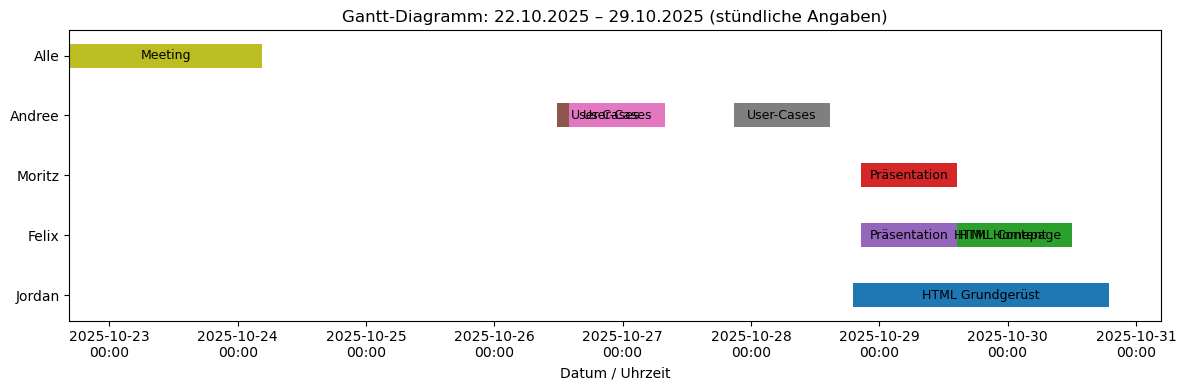

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# --- Datengrundlage ---
assignments = [
    ("Jordan", "HTML Grundgerüst", "2025-10-28 19:00", "2025-10-28 21:00"),
    ("Felix", "HTML Content", "2025-10-29 11:00", "2025-10-29 12:00"),
    ("Felix", "HTML Homepage", "2025-10-29 12:00", "2025-10-29 13:00"),
    ("Moritz", "Präsentation", "2025-10-28 20:30", "2025-10-28 21:15"),
    ("Felix", "Präsentation", "2025-10-28 20:30", "2025-10-28 21:15"),
    ("Andree", "User-Cases", "2025-10-26 11:45", "2025-10-26 12:30"),
    ("Andree", "User-Cases", "2025-10-26 14:00", "2025-10-26 14:45"),
    ("Andree", "User-Cases", "2025-10-27 20:45", "2025-10-27 21:30"),
    ("Alle", "Meeting", "2025-10-22 16:30", "2025-10-22 18:00"),
]

df_blocks = pd.DataFrame(assignments, columns=["employee","task","start","end"])
df_blocks["start"] = pd.to_datetime(df_blocks["start"])
df_blocks["end"] = pd.to_datetime(df_blocks["end"])
df_blocks["hours"] = (df_blocks["end"] - df_blocks["start"]).dt.total_seconds() / 3600

# --- Stündlicher Einsatzplan ---
week_start = datetime(2025,10,22,0,0)
week_end = datetime(2025,10,29,23,0)
hours = pd.date_range(week_start, week_end, freq="H")

rows = []
for emp in ["Jordan","Felix","Moritz", "Andree", "Alle"]:
    for hr in hours:
        assigned_task = "frei"
        for _, r in df_blocks[df_blocks["employee"]==emp].iterrows():
            if (r["start"] <= hr) and (hr < r["end"]):
                assigned_task = r["task"]
                break
        rows.append({"employee": emp, "hour_start": hr, "hour_end": hr + timedelta(hours=1), "task": assigned_task})

df_hourly = pd.DataFrame(rows)

# --- Zusammenfassung ---
summary = df_hourly[df_hourly["task"]!="frei"].groupby(["task","employee"]).size().reset_index(name="hours")
summary["hours"] = summary["hours"].astype(int)

print("\n--- Stündlicher Einsatzplan (erste Zeilen) ---")
print(df_hourly.head(20))

print("\n--- Zusammenfassung: Stunden pro Aufgabe & Mitarbeiter ---")
print(summary)

# --- Gantt-Diagramm ---
fig, ax = plt.subplots(figsize=(12,4))
employees = ["Jordan","Felix","Moritz", "Andree", "Alle"]
y_pos = {emp: i for i, emp in enumerate(employees)}

for _, r in df_blocks.iterrows():
    ax.barh(y_pos[r["employee"]], (r["end"] - r["start"]).total_seconds()/3600,
            left=mdates.date2num(r["start"]), height=0.4)
    ax.text(mdates.date2num(r["start"]) + (r["end"] - r["start"]).total_seconds()/7200,
            y_pos[r["employee"]], r["task"], va='center', ha='center', fontsize=9)

ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels(list(y_pos.keys()))
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
ax.set_xlabel("Datum / Uhrzeit")
ax.set_title("Gantt-Diagramm: 22.10.2025 – 29.10.2025 (stündliche Angaben)")
plt.tight_layout()
plt.show()

    